###  Installation de l'environnement

In [4]:
%pip install plotly-express

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install nbformat

Note: you may need to restart the kernel to use updated packages.


### Connexion à la DB DuckDB

In [1]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

### Connexion à la DB / Import des Data


In [2]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [8]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 5 tables in the database:

1. all_events
2. loaded_files
3. user_events
4. user_events_11_2019
5. user_segments_kmeans


### Import de la table DuckDB

In [9]:
DB_NAME = "amazing.duckdb"
TABLE_EVENTS = "user_events_11_2019"
TABLE_SEGMENTS = "user_segments_11_2019"
SAMPLE_USER_PERCENT = 0.2
BATCH_SIZE = 1000 

In [10]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ all_events           │
│ loaded_files         │
│ user_events          │
│ user_events_11_2019  │
│ user_segments_kmeans │
└──────────────────────┘



In [11]:
# Examine the all_events table
print(f"First 10 rows of {TABLE_EVENTS} table:")
user_events = con.sql(f"""
    SELECT * FROM {TABLE_EVENTS} ORDER BY RANDOM() LIMIT 300000
""")
user_events.show()
user_events_df = user_events.df()


First 10 rows of user_events_11_2019 table:
┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬────────────────────┬────────────────────┬─────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │    total_spent     │     avg_basket     │   last_event_time   │   conversion_rate    │    purchase_ratio    │ days_since_last_event │
│  varchar  │    int64     │   double    │     double      │         double          │       double       │       double       │      timestamp      │        double        │        double        │         int64         │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────────────────┼────────────────────┼────────────────────┼─────────────────────┼──────────────────────┼──────────────────────┼───────────────────────┤
│ 573913535 │           10 │        10.0 │             0.0 │       84115

# Matrice de Corréaltion

Text(0.5, 1.0, 'Matrice de corrélation des variables numériques')

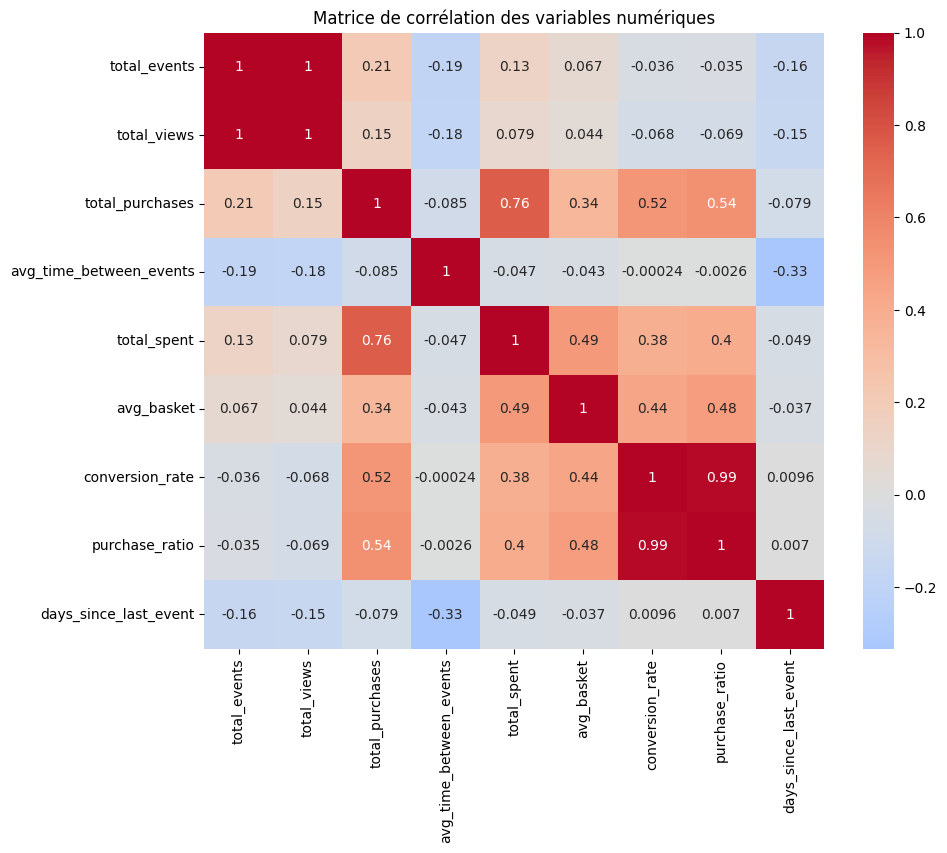

In [12]:
# Correlation between numerical columns
numeric_columns = user_events_df.select_dtypes(include=[np.number]).columns
correlation = user_events_df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des variables numériques')



# Nettoyage des clonnes inutiles

In [13]:
user_events_df.drop(columns=["days_since_last_event","conversion_rate","avg_time_between_events","purchase_ratio"], inplace=True)

# Traitements des Outliers

In [14]:
def remove_outliers_by_quantile(df, target_name, lower_quantile=0, upper_quantile=0.75, clean_cols=None):
    """
    Traite les outliers de chaque colonne numérique en remplaçant les valeurs aberrantes
    par les seuils définis par les quantiles.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame contenant les données à traiter
    target_name : str
        Nom de la colonne cible à exclure du traitement (ex: 'segment', 'CLASS')
    lower_quantile : float, default=0
        Quantile inférieur pour définir le seuil bas (valeurs en dessous seront remplacées)
    upper_quantile : float, default=0.75
        Quantile supérieur pour définir le seuil haut (valeurs au-dessus seront remplacées)
    clean_cols : list or None, default=None
        Liste des colonnes à traiter. Si None, traite toutes les colonnes numériques.
    
    Returns:
    --------
    df_cleaned : pd.DataFrame
        DataFrame avec les outliers traités
    stats : dict
        Dictionnaire contenant les statistiques de traitement pour chaque colonne
    """
    df_cleaned = df.copy()
    stats = {}
    
    # Colonnes à exclure du traitement
    exclude_cols = [target_name, 'last_event_time', 'user_id', 'event_time']
    
    # Sélectionner uniquement les colonnes numériques
    numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    # Si clean_cols est spécifié, filtrer pour ne garder que ces colonnes
    if clean_cols is not None:
        cols_to_clean = [col for col in clean_cols if col in numeric_cols]
        print(f"Colonnes sélectionnées pour le nettoyage: {cols_to_clean}")
    else:
        cols_to_clean = numeric_cols
    
    print(f"Traitement des outliers avec quantiles [{lower_quantile}, {upper_quantile}]")
    print("=" * 70)
    
    for col in numeric_cols:
        # Calculer les seuils pour toutes les colonnes (pour les stats)
        lower_threshold = df_cleaned[col].quantile(lower_quantile)
        upper_threshold = df_cleaned[col].quantile(upper_quantile)
        
        # Compter les outliers avant traitement
        lower_outliers = (df_cleaned[col] < lower_threshold).sum()
        upper_outliers = (df_cleaned[col] > upper_threshold).sum()
        total_outliers = lower_outliers + upper_outliers
        
        # Stocker les statistiques pour toutes les colonnes
        stats[col] = {
            'lower_threshold': lower_threshold,
            'upper_threshold': upper_threshold,
            'lower_outliers_count': lower_outliers,
            'upper_outliers_count': upper_outliers,
            'total_outliers': total_outliers,
            'outliers_percentage': (total_outliers / len(df_cleaned)) * 100,
            'cleaned': col in cols_to_clean  # Marquer si la colonne a été nettoyée
        }
        
        # Remplacer les outliers UNIQUEMENT pour les colonnes sélectionnées
        if col in cols_to_clean:
            df_cleaned[col] = df_cleaned[col].clip(lower=lower_threshold, upper=upper_threshold)
            
            # Afficher les résultats si des outliers ont été traités
            if total_outliers > 0:
                print(f"\n✓ {col} [NETTOYÉE]:")
                print(f"  Seuil inférieur ({lower_quantile*100}%): {lower_threshold:.2f}")
                print(f"  Seuil supérieur ({upper_quantile*100}%): {upper_threshold:.2f}")
                print(f"  Outliers bas remplacés: {lower_outliers}")
                print(f"  Outliers hauts remplacés: {upper_outliers}")
                print(f"  Total: {total_outliers} ({stats[col]['outliers_percentage']:.2f}%)")
        else:
            # Juste afficher les stats sans nettoyer
            if total_outliers > 0:
                print(f"\n○ {col} [NON NETTOYÉE]:")
                print(f"  Outliers détectés: {total_outliers} ({stats[col]['outliers_percentage']:.2f}%)")
    
    print("\n" + "=" * 70)
    total_cleaned_outliers = sum([s['total_outliers'] for s in stats.values() if s['cleaned']])
    total_all_outliers = sum([s['total_outliers'] for s in stats.values()])
    print(f"Total d'outliers traités: {total_cleaned_outliers}/{total_all_outliers}")
    
    return df_cleaned, stats


def plot_outlier_treatment_comparison(df_original, df_cleaned, target_name, stats):
    """
    Visualise l'effet du traitement des outliers sur les données.
    Affiche TOUTES les colonnes, mais marque celles qui ont été nettoyées.
    
    Parameters:
    -----------
    df_original : pd.DataFrame
        DataFrame original avant traitement
    df_cleaned : pd.DataFrame
        DataFrame après traitement
    target_name : str
        Nom de la colonne cible
    stats : dict
        Statistiques retournées par remove_outliers_by_quantile
    """
    # Toutes les colonnes avec stats
    all_cols = list(stats.keys())
    
    if not all_cols:
        print("Aucune colonne n'a été analysée")
        return
    
    n_cols = len(all_cols)
    n_rows = (n_cols + 2) // 3  # 3 colonnes par ligne
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 5))
    axes = axes.flatten() if n_cols > 1 else [axes]
    
    for idx, col in enumerate(all_cols):
        ax = axes[idx]
        
        # Boxplot avant/après
        data_to_plot = [
            df_original[col].dropna(),
            df_cleaned[col].dropna()
        ]
        
        bp = ax.boxplot(data_to_plot, labels=['Avant', 'Après'], patch_artist=True)
        
        # Colorer différemment selon si la colonne a été nettoyée ou non
        if stats[col]['cleaned']:
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightgreen')
            title_prefix = "✓ NETTOYÉE"
        else:
            bp['boxes'][0].set_facecolor('lightgray')
            bp['boxes'][1].set_facecolor('lightgray')
            title_prefix = "○ NON NETTOYÉE"
        
        # Ajouter les seuils
        lower = stats[col]['lower_threshold']
        upper = stats[col]['upper_threshold']
        ax.axhline(y=lower, color='blue', linestyle='--', alpha=0.5, label=f'Seuil bas: {lower:.2f}')
        ax.axhline(y=upper, color='red', linestyle='--', alpha=0.5, label=f'Seuil haut: {upper:.2f}')
        
        ax.set_title(f'{title_prefix} - {col}\n{stats[col]["total_outliers"]} outliers ({stats[col]["outliers_percentage"]:.1f}%)')
        ax.set_ylabel('Valeur')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Masquer les axes vides
    for idx in range(len(all_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Comparaison avant/après traitement des outliers', fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()

In [15]:
## Traiter uniquement certaines colonnes
#user_events_cleaned, outlier_stats = remove_outliers_by_quantile(
#    user_events_df, 
#    target_name='segment',
#    lower_quantile=0, 
#    upper_quantile=1,
#    clean_cols=['total_events', 'purchase_count', 'avg_price', 'avg_basket']  # Seulement ces colonnes seront nettoyées
#)
#
## La visualisation affichera TOUTES les colonnes, mais marquera celles qui ont été nettoyées
#plot_outlier_treatment_comparison(user_events_df, user_events_cleaned, 'segment', outlier_stats)
#
## Afficher les statistiques détaillées
#print("\nStatistiques détaillées par colonne:")
#for col, stat in outlier_stats.items():
#    status = "NETTOYÉE" if stat['cleaned'] else "NON NETTOYÉE"
#    print(f"\n{col} [{status}]: {stat}")

In [16]:
user_events_cleaned = user_events_df.copy()

In [17]:
user_events_cleaned.describe()

,total_events,total_views,total_purchases,total_spent,avg_basket,last_event_time
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000
mean,44.262963,41.620440,0.596977,177.116114,70.104709,2019-11-21 19:56:56.971447
min,10.000000,0.000000,0.000000,0.000000,0.000000,2019-11-01 00:10:40
25%,15.000000,14.000000,0.000000,0.000000,0.000000,2019-11-16 20:19:58.750000
50%,25.000000,23.000000,0.000000,0.000000,0.000000,2019-11-23 03:34:17
75%,48.000000,45.000000,1.000000,25.420000,21.882000,2019-11-28 09:31:43.500000
max,22929.000000,22926.000000,268.000000,161682.490000,2574.070000,2019-11-30 23:59:55
std,80.417105,78.675445,2.038904,967.080612,193.513921,NaN


### Normalisation et Standardisation des données

In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Sélectionner les features numériques
numeric_features = user_events_cleaned.drop(columns=["last_event_time"])

# Option 1: Standardisation (Z-score normalization) - moyenne=0, écart-type=1
print("Standardisation des données...")
std_scaler = StandardScaler()
X_standardized = std_scaler.fit_transform(numeric_features)
print(f"Shape après standardisation: {X_standardized.shape}")
print(f"Moyenne après standardisation: {X_standardized.mean(axis=0)[:3]}...")  # ~0
print(f"Écart-type après standardisation: {X_standardized.std(axis=0)[:3]}...")  # ~1

# Choisir quelle méthode utiliser pour le clustering
# Recommandation: StandardScaler pour KMeans (plus robuste aux outliers)
X_num_scaled = X_standardized  # ou X_normalized selon votre choix

print("\n" + "="*70)
print(f"Méthode choisie: {'Standardisation' if X_num_scaled is X_standardized else 'Normalisation'}")
print(f"Shape finale: {X_num_scaled.shape}")

Standardisation des données...
Shape après standardisation: (300000, 6)
Moyenne après standardisation: [ 1.88966472e-15  1.70530257e-17 -3.06954462e-17]...
Écart-type après standardisation: [1. 1. 1.]...

Méthode choisie: Standardisation
Shape finale: (300000, 6)


In [19]:
X_num_scaled.shape

(300000, 6)

In [20]:
X_num_scaled

array([[-1.15146387,  0.10864668,  0.14463953, -0.29279342, -0.18314545,
        -0.36227278],
       [ 0.01684641, -0.40119595, -0.37648963, -0.29279342, -0.18314545,
        -0.36227278],
       [-0.93177599, -0.27684409, -0.24938496, -0.29279342, -0.18314545,
        -0.36227278],
       ...,
       [-0.04086492, -0.10275149, -0.13499076,  0.68812739,  0.35525938,
         0.98305903],
       [ 1.1518373 , -0.3638904 , -0.33835823, -0.29279342, -0.18314545,
        -0.36227278],
       [-0.44336692, -0.33902002, -0.3129373 , -0.29279342, -0.18314545,
        -0.36227278]], shape=(300000, 6))

In [21]:
user_events_df.describe()

,total_events,total_views,total_purchases,total_spent,avg_basket,last_event_time
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000
mean,44.262963,41.620440,0.596977,177.116114,70.104709,2019-11-21 19:56:56.971447
min,10.000000,0.000000,0.000000,0.000000,0.000000,2019-11-01 00:10:40
25%,15.000000,14.000000,0.000000,0.000000,0.000000,2019-11-16 20:19:58.750000
50%,25.000000,23.000000,0.000000,0.000000,0.000000,2019-11-23 03:34:17
75%,48.000000,45.000000,1.000000,25.420000,21.882000,2019-11-28 09:31:43.500000
max,22929.000000,22926.000000,268.000000,161682.490000,2574.070000,2019-11-30 23:59:55
std,80.417105,78.675445,2.038904,967.080612,193.513921,NaN


In [22]:
tmp_user_events_df = user_events_df.copy()
tmp_user_events_df.reset_index(drop=True, inplace=True)

In [23]:
# Replace for Using category embeddings
#X_final = np.hstack([X_num_scaled, X_emb_scaled])
X_final = X_num_scaled

### Choix du Nombre de Clusters, Analyse du Coude et Analyse de la struture des clusters

Analyse du coude pour déterminer le nombre optimal de clusters...


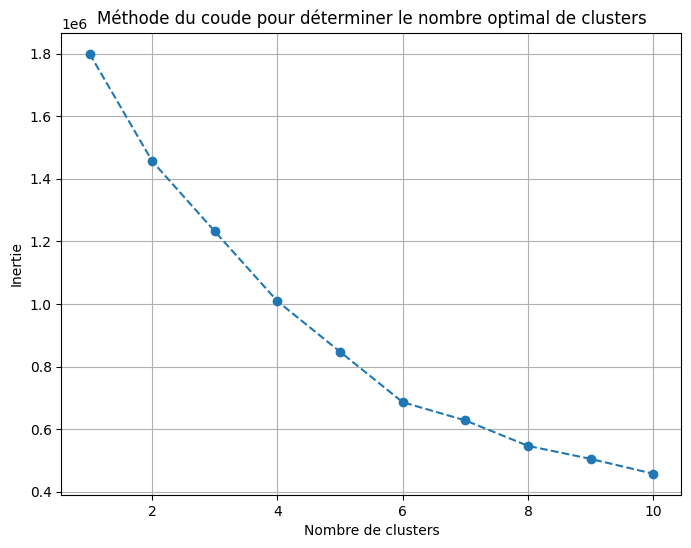

In [24]:

# Analyse du Coude (Elbow Method)
print("Analyse du coude pour déterminer le nombre optimal de clusters...")

inertia = []
cluster_range = range(1, 11)  # Test cluster counts from 1 to 10

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_final)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(cluster_range, inertia, marker='o', linestyle='--')
plt.title("Méthode du coude pour déterminer le nombre optimal de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.grid(True)
plt.show()

### Analyse Silhouette, Calinski-Harabasz & Davies-Bouldin

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Define the range of clusters to evaluate
ks = range(2, 11)

# Initialize lists to store the scores
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

# Evaluate clustering for each k
for k in ks:
    km = KMeans(n_clusters=k, random_state=42).fit(X_final)
    labels = km.labels_
    
    # Compute the metrics
    silhouette_scores.append(silhouette_score(X_final, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_final, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_final, labels))

# Plot the metrics
plt.figure(figsize=(15, 5))

# Silhouette Coefficient
plt.subplot(1, 3, 1)
plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
plt.title("Silhouette Coefficient")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

# Calinski–Harabasz Index
plt.subplot(1, 3, 2)
plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
plt.title("Calinski–Harabasz Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

# Davies–Bouldin Index
plt.subplot(1, 3, 3)
plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
plt.title("Davies–Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
# Récupérer les noms de colonnes depuis numeric_features
X_final_df = pd.DataFrame(X_final, columns=numeric_features.columns)

# Afficher les statistiques descriptives
X_final_df.describe()

,user_id,total_events,total_views,total_purchases,total_spent,avg_basket
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,1.040235e-15,-1.847411e-17,-9.947598e-18,-1.065814e-17,-1.421085e-18,2.700062e-17
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-1.839029e+01,-5.548375e-01,-6.863344e-01,-3.339520e-01,-1.946912e-01,-3.607131e-01
25%,-9.212477e-01,-4.719794e-01,-4.631027e-01,-3.339520e-01,-1.946912e-01,-3.607131e-01
50%,-8.942990e-02,-3.228349e-01,-3.085577e-01,-3.339520e-01,-1.946912e-01,-3.607131e-01
75%,9.614957e-01,5.831219e-02,6.921899e-02,2.598460e-01,-1.736630e-01,-2.951747e-01
max,1.634520e+00,2.125341e+01,2.143077e+01,2.163658e+01,4.377171e+01,8.939715e+00


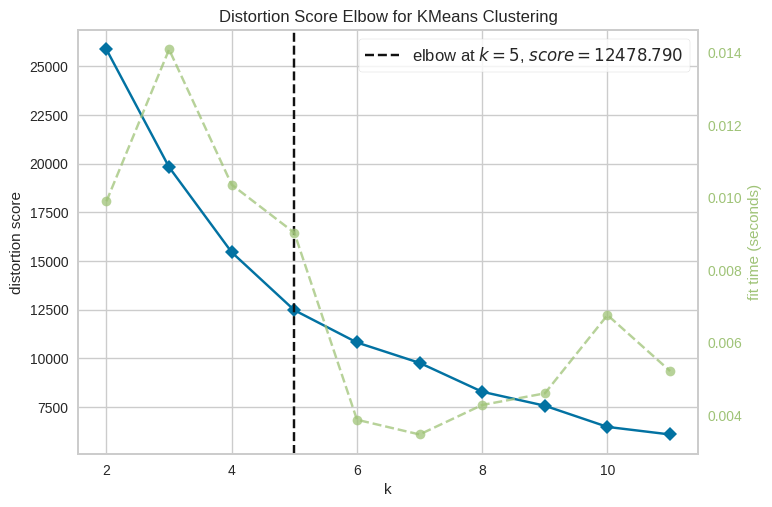

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# Elbow Visualizer 
# Note: n_clusters must be specified even though KElbowVisualizer will override it
km = KMeans(n_clusters=4, random_state=42)
visualizer = KElbowVisualizer(km, k=(2, 12), force_model=True)
 
visualizer.fit(X_final)     
visualizer.show()

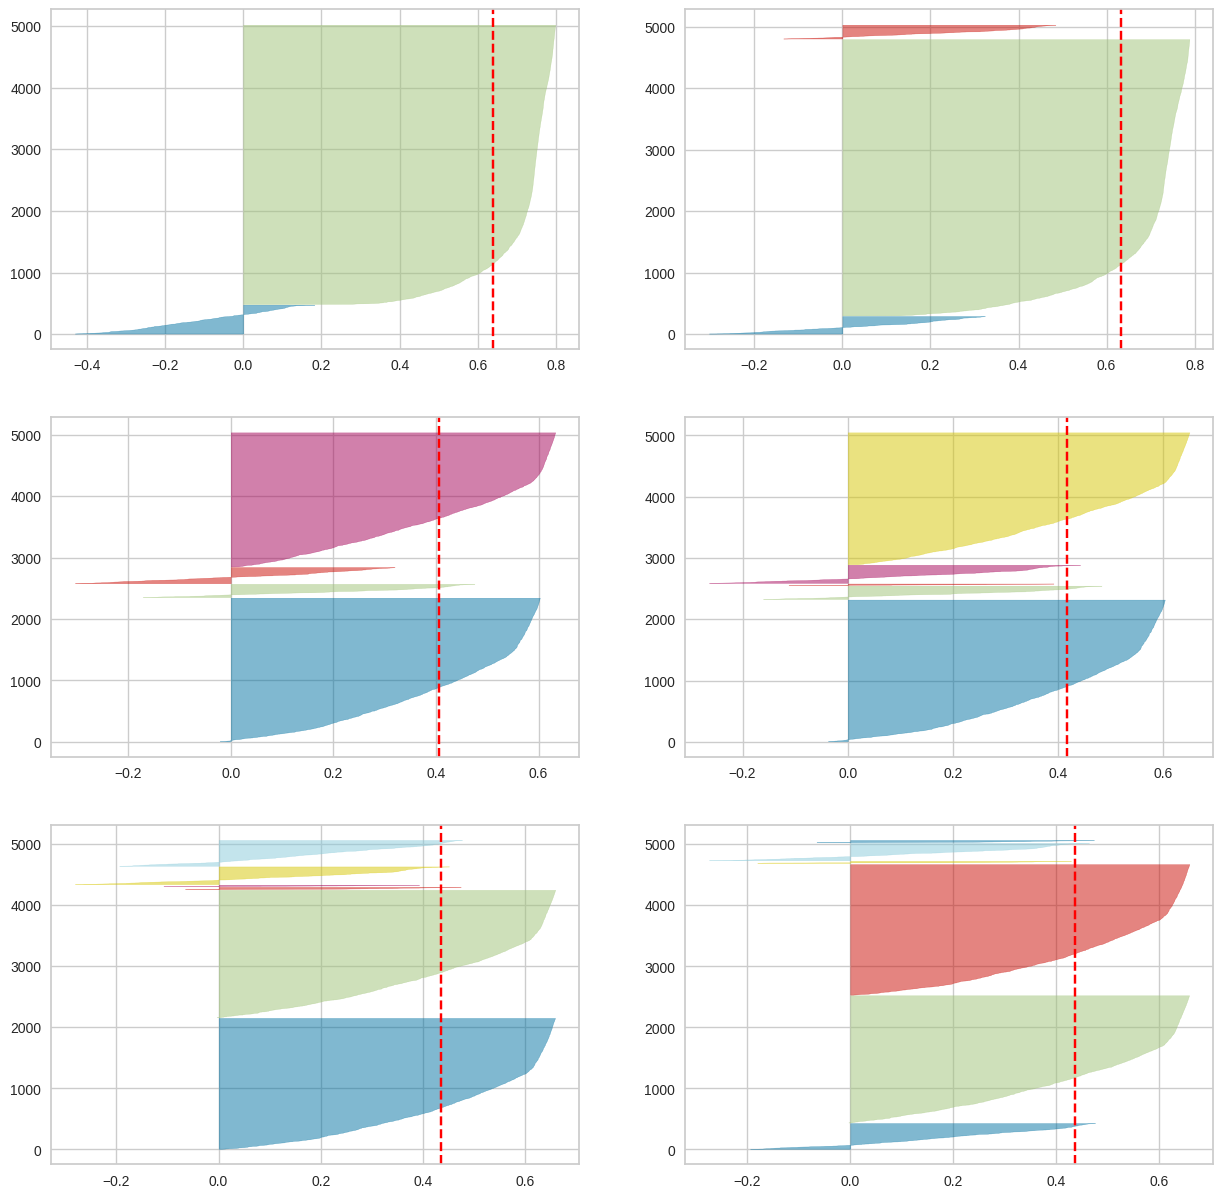

In [ ]:


# Ploting silhouette score for each cluster.
fig, ax = plt.subplots(3, 2, figsize=(15,15))
for i in [2, 3, 4, 5,6,7]:
    '''
    Create KMeans instances for different number of clusters
    '''
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)
    '''
    Create SilhouetteVisualizer instance with KMeans instance
    Fit the visualizer
    '''
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod], force_model=True)
    visualizer.fit(X_final) 



### Fit et Plot KMeans

In [ ]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.offline as py
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd


def kmeans_fit_and_plot_per_cluster(k, X_final, df):
    df_tmp = df.copy()
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_final)
    df_tmp["segment"] = clusters

    # --- Silhouette Analysis ---
    print("Silhouette Analysis...")
    silhouette_avg = silhouette_score(X_final, clusters)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(X_final, clusters)

    # Print silhouette score for each cluster
    for cluster in range(k):
        cluster_silhouette_avg = sample_silhouette_values[clusters == cluster].mean()
        print(f"Silhouette score for Cluster {cluster}: {cluster_silhouette_avg}")

    # Define consistent colors for clusters
    colormap = plt.colormaps.get_cmap("tab10")
    cluster_colors = [mcolors.to_hex(colormap(i)) for i in range(k)]
    cluster_color_map = {i: cluster_colors[i] for i in range(k)}  # Map cluster index to color

    # --- Silhouette Plot ---
    plt.figure(figsize=(10, 8))
    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cluster_color_map[i]
        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    plt.title(f"Silhouette analysis for KMeans clustering on sample data with n_clusters = {k}")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])
    plt.xticks(np.arange(-0.1, 1.1, 0.1))
    plt.show()

    # --- PCA Scatter Plot (2D) ---
    print("Visualisation du clustering (2D)...")
    pca = PCA(n_components=2)
    X_pca_2d = pca.fit_transform(X_final)

    plt.figure(figsize=(10, 8))
    for i in range(k):
        cluster_points = X_pca_2d[clusters == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=cluster_color_map[i], label=f"Cluster {i}", s=10)

    plt.title(f"Visualisation des clusters utilisateurs (PCA 2D)- K = {k}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- PCA Scatter Plot (3D) ---
    print("Visualisation du clustering (3D)...")
    pca_3d = PCA(n_components=3)
    X_pca_3d = pca_3d.fit_transform(X_final)

    # Prepare data for Plotly
    traces = []
    for i in range(k):
        cluster_points = X_pca_3d[clusters == i]
        trace = go.Scatter3d(
            x=cluster_points[:, 0],
            y=cluster_points[:, 1],
            z=cluster_points[:, 2],
            mode='markers',
            marker=dict(
                size=8,
                color=cluster_color_map[i],  # Use consistent cluster color
                opacity=0.8
            ),
            name=f"Cluster {i}"
        )
        traces.append(trace)

    layout = go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        title="Interactive 3D Plot of Clusters"
    )
    fig = go.Figure(data=traces, layout=layout)
    py.iplot(fig, filename='3d-scatter-colorscale')

    return df_tmp

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_stats(df, segment_column="segment"):
    """
    Plots statistics, distributions, and boxplots for clusters in the DataFrame.

    Parameters:
    - df: DataFrame containing the clustering results and features.
    - segment_column: Name of the column containing cluster segments.

    Returns:
    - stats: A dictionary containing descriptive statistics for each cluster.
    """
    # Ensure the segment column exists
    if segment_column not in df.columns:
        raise ValueError(f"Column '{segment_column}' not found in the DataFrame.")

    # Number of individuals per cluster
    cluster_counts = df[segment_column].value_counts().sort_index()
    print("Number of individuals per cluster:")
    print(cluster_counts)

    # Plot the distribution of individuals per cluster
    plt.figure(figsize=(10, 6))
    cluster_counts.plot(kind="bar", color="skyblue", alpha=0.8)
    plt.title("Distribution of Individuals per Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Number of Individuals")
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    # Descriptive statistics for each cluster
    stats = {}
    for cluster in cluster_counts.index:
        cluster_data = df[df[segment_column] == cluster]
        cluster_stats = cluster_data.describe()
        stats[cluster] = cluster_stats
        print(f"\nDescriptive statistics for Cluster {cluster}:")
        print(cluster_stats)

    # Boxplots for each column grouped by cluster
    numeric_columns = df.select_dtypes(include=["number"]).columns
    numeric_columns = [col for col in numeric_columns if col != segment_column]

    for col in numeric_columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x=segment_column, y=col, data=df, palette="Set3")
        plt.title(f"Boxplot of {col} by Cluster")
        plt.xlabel("Cluster")
        plt.ylabel(col)
        plt.grid(axis="y", linestyle="--", alpha=0.7)
        plt.show()

    return stats

Silhouette Analysis...
For n_clusters = 4, the average silhouette_score is: 0.4196341679885249
Silhouette score for Cluster 0: 0.22683888646898442
Silhouette score for Cluster 1: 0.4533108322131607
Silhouette score for Cluster 2: 0.4401731352859399
Silhouette score for Cluster 3: 0.06045345267810959


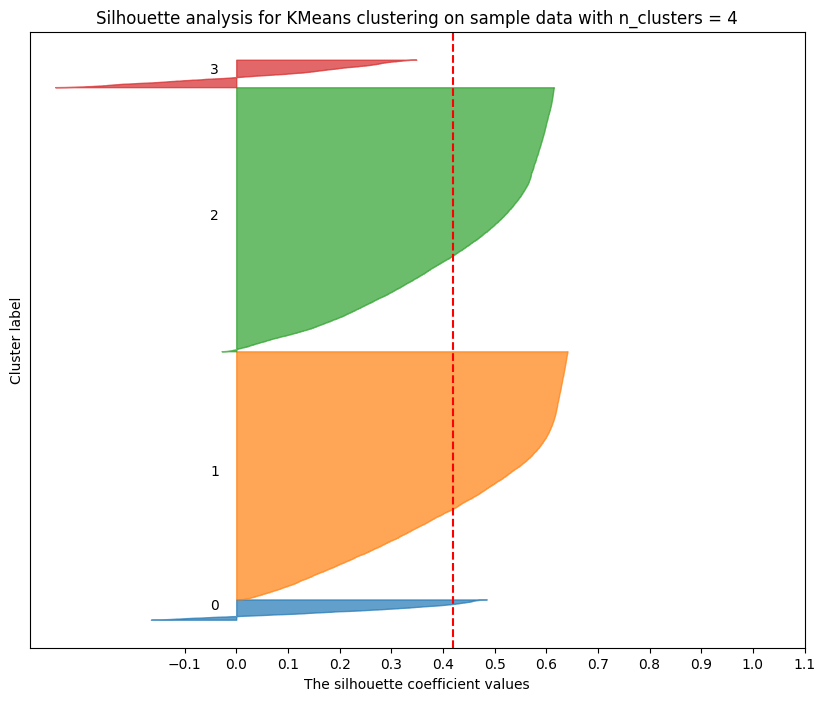

Visualisation du clustering (2D)...


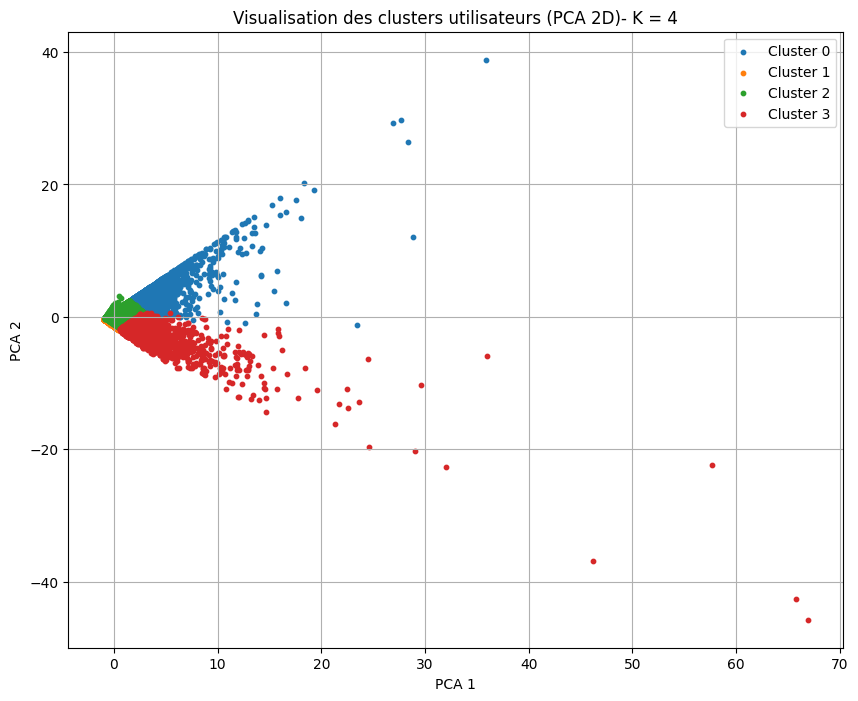

Visualisation du clustering (3D)...


In [ ]:
N_CLUSTERS = 4

df_kmeans = kmeans_fit_and_plot_per_cluster(N_CLUSTERS, X_final, user_events_df)

In [ ]:
df_kmeans["segment"].value_counts()

segment
2    23580
1    22155
3     2453
0     1812
Name: count, dtype: int64

Number of individuals per cluster:
segment
0     1812
1    22155
2    23580
3     2453
Name: count, dtype: int64


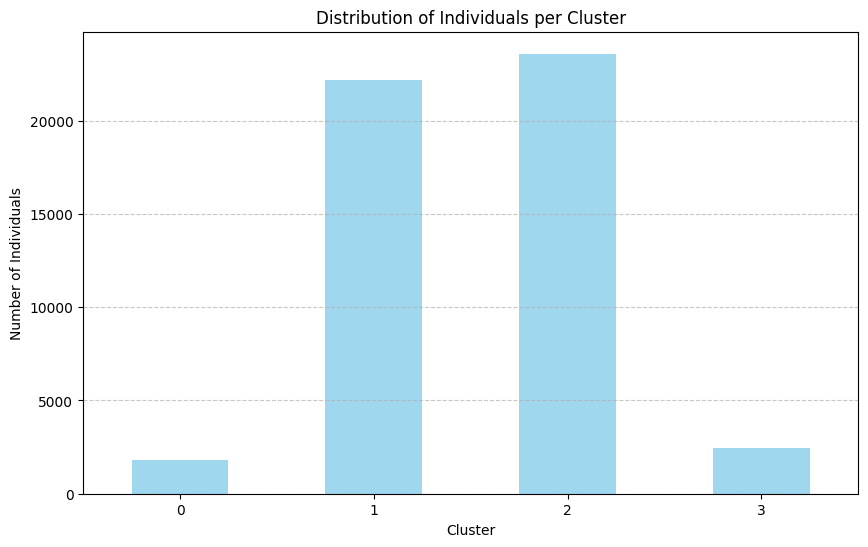


Descriptive statistics for Cluster 0:
       total_events  total_views  total_purchases  total_spent   avg_basket  \
count   1812.000000  1812.000000      1812.000000  1812.000000  1812.000000   
mean     275.530353   265.980132         1.607064   277.091882    95.693256   
min      147.000000   110.000000         0.000000     0.000000     0.000000   
25%      183.000000   177.000000         0.000000     0.000000     0.000000   
50%      224.000000   214.000000         1.000000    48.895000    34.125000   
75%      303.000000   293.000000         2.000000   299.712500   145.226875   
max     2407.000000  2407.000000        49.000000  7777.310000  1186.070000   
std      163.690742   161.458314         2.869346   609.070608   139.848975   

                  last_event_time  segment  
count                        1812   1812.0  
mean   2019-11-26 11:13:03.833333      0.0  
min           2019-11-04 03:44:53      0.0  
25%           2019-11-23 18:13:50      0.0  
50%    2019-11-28 11:50:

/tmp/ipykernel_145087/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




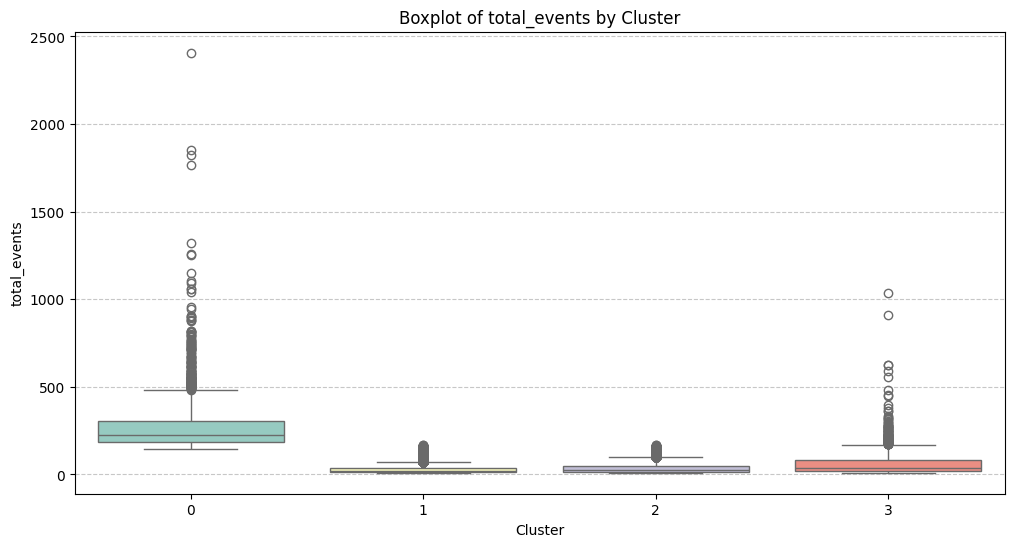

/tmp/ipykernel_145087/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




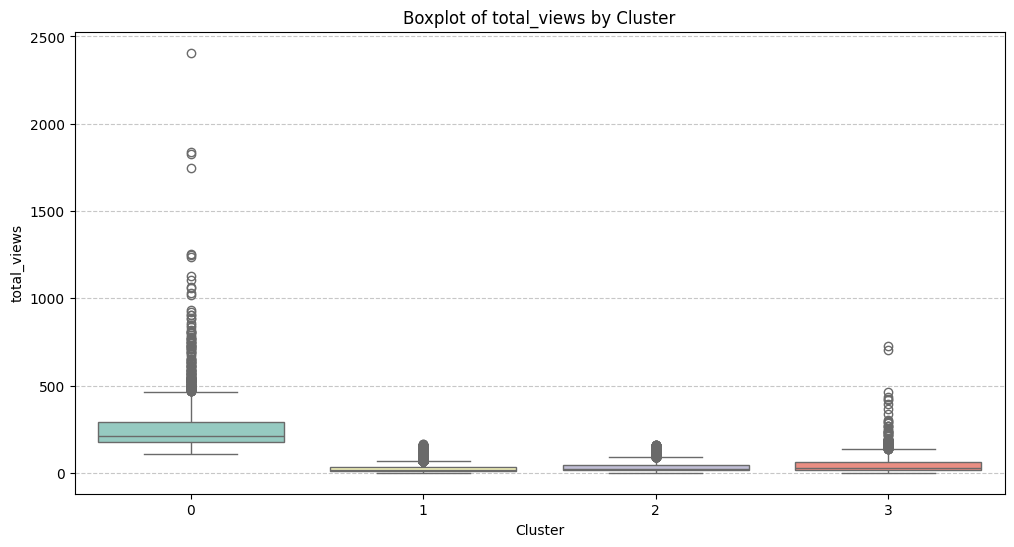

/tmp/ipykernel_145087/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




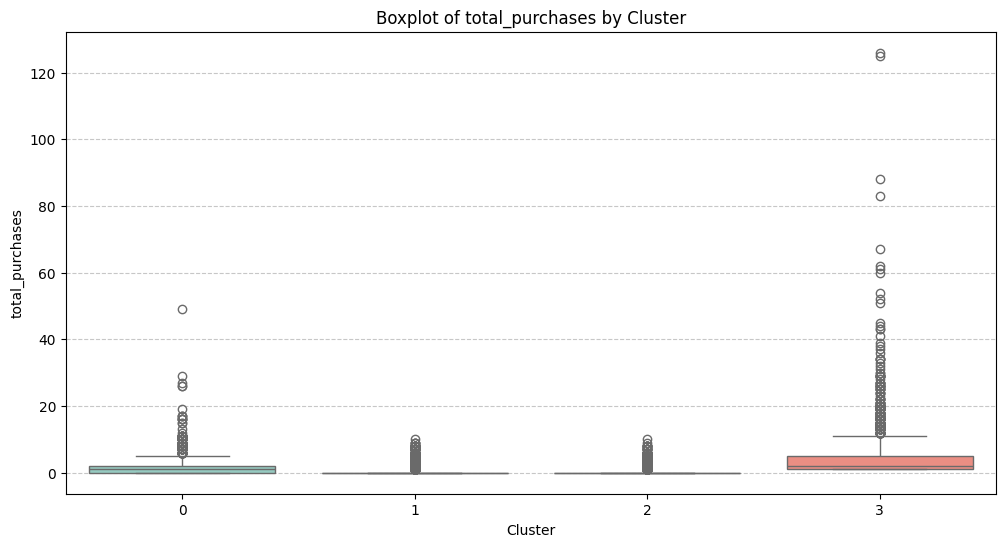

/tmp/ipykernel_145087/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




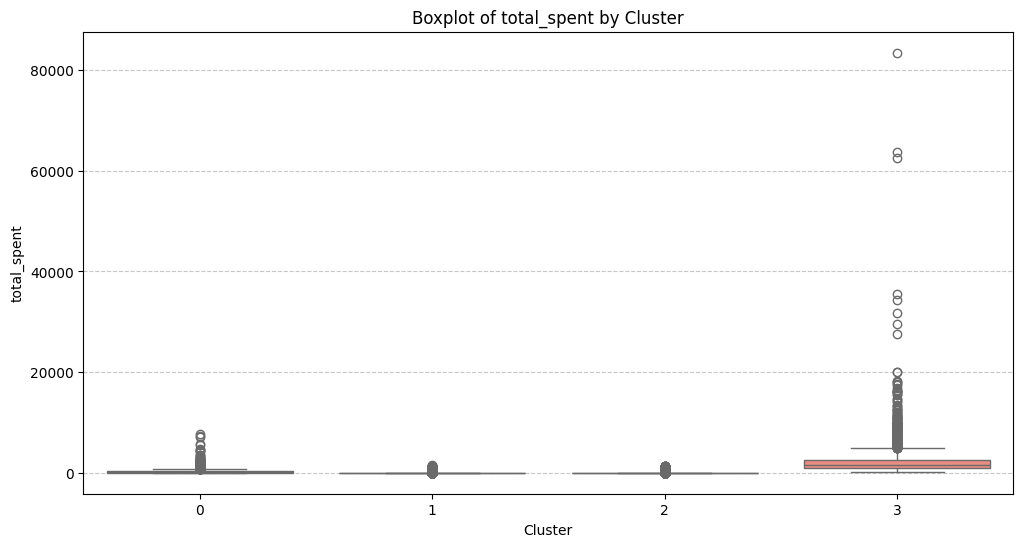

/tmp/ipykernel_145087/2013640284.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




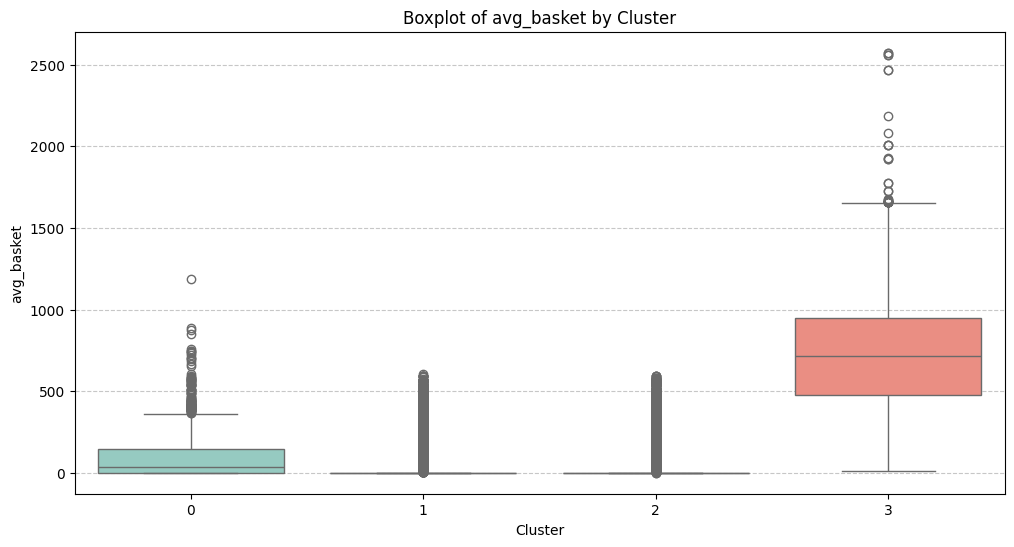

{0:        total_events  total_views  total_purchases  total_spent   avg_basket  \
 count   1812.000000  1812.000000      1812.000000  1812.000000  1812.000000   
 mean     275.530353   265.980132         1.607064   277.091882    95.693256   
 min      147.000000   110.000000         0.000000     0.000000     0.000000   
 25%      183.000000   177.000000         0.000000     0.000000     0.000000   
 50%      224.000000   214.000000         1.000000    48.895000    34.125000   
 75%      303.000000   293.000000         2.000000   299.712500   145.226875   
 max     2407.000000  2407.000000        49.000000  7777.310000  1186.070000   
 std      163.690742   161.458314         2.869346   609.070608   139.848975   
 
                   last_event_time  segment  
 count                        1812   1812.0  
 mean   2019-11-26 11:13:03.833333      0.0  
 min           2019-11-04 03:44:53      0.0  
 25%           2019-11-23 18:13:50      0.0  
 50%    2019-11-28 11:50:21.500000      0.0  

In [ ]:
plot_cluster_stats(df_kmeans, segment_column="segment")

### Sauvegarde du DataFrame en Table DuckDB

In [ ]:
con.execute(f"DROP TABLE IF EXISTS {TABLE_SEGMENTS}_kmeans")

con.execute(f"""
CREATE TABLE {TABLE_SEGMENTS}_kmeans AS
SELECT * FROM df_kmeans
""")

print("Clustering sauvegardé avec succès !")


Clustering sauvegardé avec succès !


In [ ]:
user_segments = con.sql(f"""
    SELECT * FROM {TABLE_SEGMENTS}_kmeans
""")
user_segments.show()

┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────┬────────────────────┬─────────────────────┬─────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ total_spent │     avg_basket     │   last_event_time   │ segment │
│  varchar  │    int64     │   double    │     double      │   double    │       double       │      timestamp      │  int32  │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────┼────────────────────┼─────────────────────┼─────────┤
│ 560358767 │           43 │        24.0 │             5.0 │      275.05 │ 55.010000000000005 │ 2019-11-30 03:44:54 │       1 │
│ 522718584 │           14 │        14.0 │             0.0 │         0.0 │                0.0 │ 2019-11-15 05:52:15 │       2 │
│ 515085265 │           12 │        12.0 │             0.0 │         0.0 │                0.0 │ 2019-11-28 05:05:29 │       2 │
│ 567022717 │           12 │        12.0 │             0.0 │         0.0 │                0.0 │ 2019-11-

In [ ]:
user_segments.df()["segment"].value_counts()

segment
2    23580
1    22155
3     2453
0     1812
Name: count, dtype: int64

In [3]:
# Fermeture de la connexion DuckDB
con.close()